In [1]:
import os
print(os.getcwd())

C:\Users\berka


In [2]:
import pandas as pd

df = pd.read_csv("insurance.csv")
print(df.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [3]:
print(df.columns)
print(df.info())

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


In [4]:
df.groupby("smoker")["charges"].mean()

smoker
no      8434.268298
yes    32050.231832
Name: charges, dtype: float64

In [5]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [8]:
df.groupby("smoker")["charges"].mean()

smoker
no      8434.268298
yes    32050.231832
Name: charges, dtype: float64

In [9]:
#“Sigara kullanan bireylerin maliyeti yaklaşık 4 kat daha yüksektir.”

<Axes: title={'center': 'charges'}, xlabel='smoker'>

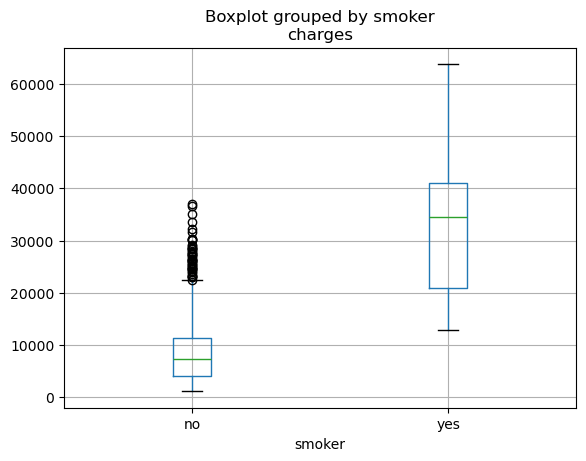

In [10]:
df.boxplot(column="charges", by="smoker")

<Axes: xlabel='age'>

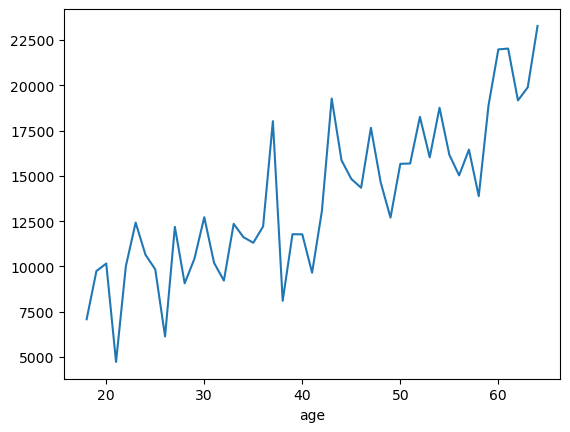

In [11]:
df.groupby("age")["charges"].mean().plot()

In [12]:
#yaşa bağlı riskin grafiği

In [13]:
df.groupby("smoker")["charges"].mean()

smoker
no      8434.268298
yes    32050.231832
Name: charges, dtype: float64

In [14]:
#şimdi buradan sonra sigara içenlerin içmeyenlere göre ort. maliyetini göreceğiz

In [15]:
print(df.groupby("smoker")["charges"].mean())

smoker
no      8434.268298
yes    32050.231832
Name: charges, dtype: float64


In [16]:
df["smoker"].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

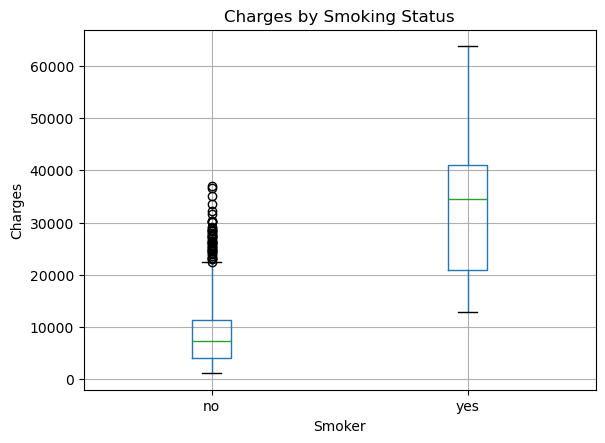

In [17]:
import matplotlib.pyplot as plt

df.boxplot(column="charges", by="smoker")
plt.title("Charges by Smoking Status")
plt.suptitle("")
plt.xlabel("Smoker")
plt.ylabel("Charges")
plt.show()

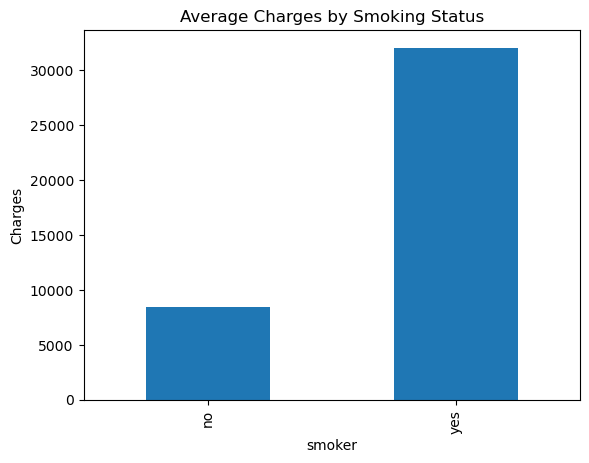

In [18]:
df.groupby("smoker")["charges"].mean().plot(kind="bar")
plt.title("Average Charges by Smoking Status")
plt.ylabel("Charges")
plt.show()

In [19]:
df = pd.get_dummies(df, drop_first=True)

In [20]:
X = df.drop("charges", axis=1)
y = df["charges"]

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
predictions = model.predict(X_test)

In [24]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, predictions)
print(r2)

0.7835929767120724


In [25]:
import pandas as pd

coeff = pd.DataFrame(model.coef_, X.columns, columns=["coef"])
print(coeff.sort_values(by="coef", ascending=False))

                          coef
smoker_yes        23651.128856
children            425.278784
bmi                 337.092552
age                 256.975706
sex_male            -18.591692
region_northwest   -370.677326
region_southeast   -657.864297
region_southwest   -809.799354


In [26]:
# 1. Kategorik değişkenleri sayıya çevirmemiz lazım
df = pd.get_dummies(df, drop_first=True)

# 2. X ve y ayır
X = df.drop("charges", axis=1)
y = df["charges"]

# 3. Train / Test böl
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Model kur
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

# 5. Tahmin yap
predictions = model.predict(X_test)

# 6. R² hesapla
from sklearn.metrics import r2_score

r2 = r2_score(y_test, predictions)
print("R² değeri:", r2)

R² değeri: 0.7835929767120724


In [27]:
import pandas as pd

coeff = pd.DataFrame(model.coef_, X.columns, columns=["Coefficient"])
print(coeff.sort_values(by="Coefficient", ascending=False))

                   Coefficient
smoker_yes        23651.128856
children            425.278784
bmi                 337.092552
age                 256.975706
sex_male            -18.591692
region_northwest   -370.677326
region_southeast   -657.864297
region_southwest   -809.799354


In [28]:
plt.savefig("smoker_plot.png")

<Figure size 640x480 with 0 Axes>

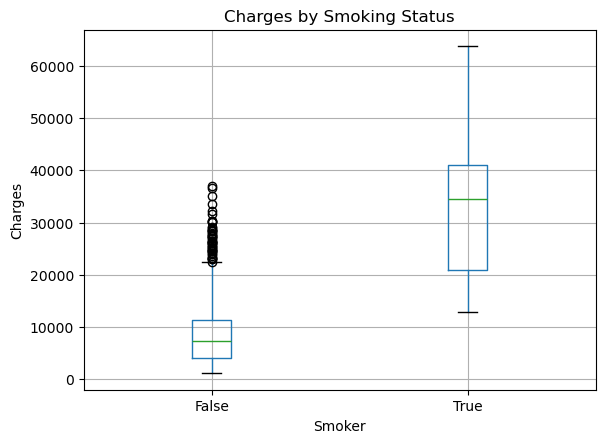

In [31]:
import matplotlib.pyplot as plt

# Grafik oluştur
df.boxplot(column="charges", by="smoker_yes")

# Başlıkları düzenle
plt.title("Charges by Smoking Status")
plt.suptitle("")
plt.xlabel("Smoker")
plt.ylabel("Charges")

# KAYDET (EN KRİTİK SATIR)
plt.savefig("smoker_plot.png", dpi=300, bbox_inches='tight')

# Sonra göster
plt.show()

In [32]:
import os
print(os.getcwd())

C:\Users\berka
